# Sales Data Analysis using Python
**Exploratory Data Analysis (EDA) on a multi-category retail sales dataset**

This notebook performs end-to-end EDA on a retail sales dataset spanning 7 product categories across 5 regions in India, over 2024. The goal is to identify revenue drivers, seasonal trends, and customer purchase patterns that can support inventory and sales strategy decisions.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('data/sales_data.csv', parse_dates=['order_date'])
df.head()

,order_id,order_date,category,unit_price,quantity,discount_pct,region,payment_mode,customer_rating,gross_sales,net_sales
0,100001,2024-04-12,Sports & Fitness,1427.23,1,10,South,Credit Card,5.0,1427.23,1284.51
1,100002,2024-05-29,Electronics,32906.95,2,0,West,Credit Card,4.6,65813.90,65813.90
2,100003,2024-11-09,Home & Kitchen,4996.84,1,10,South,Credit Card,4.3,4996.84,4497.16
3,100004,2024-12-29,Home & Kitchen,6749.17,1,10,Central,Debit Card,3.6,6749.17,6074.25
4,100005,2024-09-30,Grocery,1450.17,2,0,Central,Credit Card,4.6,2900.34,2900.34


## 1. Data Cleaning & Preprocessing

In [2]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (5015, 11)

Missing values:
 order_id            0
order_date          0
category            0
unit_price          0
quantity            0
discount_pct        0
region              0
payment_mode        0
customer_rating    60
gross_sales         0
net_sales           0
dtype: int64

Duplicate rows: 15


In [3]:
# Drop exact duplicates
df = df.drop_duplicates()

# Fill missing customer ratings with the category-level median rating
df['customer_rating'] = df.groupby('category')['customer_rating'].transform(
    lambda x: x.fillna(x.median())
)

# Add helper time columns
df['month'] = df['order_date'].dt.month_name()
df['month_num'] = df['order_date'].dt.month
df['weekday'] = df['order_date'].dt.day_name()

print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:", df.isnull().sum().sum())

Shape after cleaning: (5000, 14)
Missing values after cleaning: 0


## 2. Revenue Overview

In [4]:
total_revenue = df['net_sales'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = df['net_sales'].mean()

print(f"Total Net Revenue: Rs {total_revenue:,.0f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: Rs {avg_order_value:,.0f}")

Total Net Revenue: Rs 43,162,356
Total Orders: 5,000
Average Order Value: Rs 8,632


## 3. Revenue by Category

/tmp/ipykernel_564/2948231026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, palette="viridis")


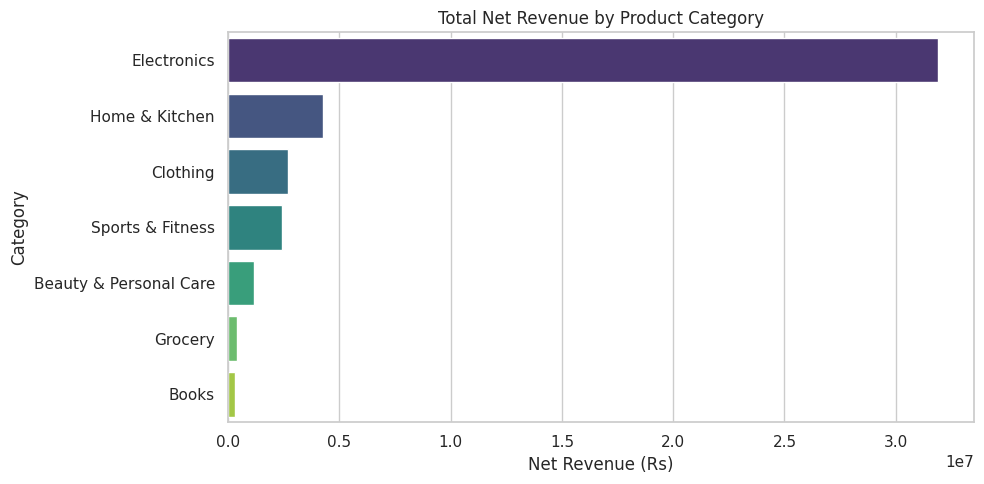

category
Electronics               31920240.65
Home & Kitchen             4275421.32
Clothing                   2679965.01
Sports & Fitness           2427197.24
Beauty & Personal Care     1142014.36
Grocery                     412071.59
Books                       305446.17
Name: net_sales, dtype: float64

In [5]:
category_revenue = df.groupby('category')['net_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette="viridis")
plt.title("Total Net Revenue by Product Category")
plt.xlabel("Net Revenue (Rs)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("images/revenue_by_category.png", dpi=150)
plt.show()

category_revenue

**Insight:** Electronics is the leading revenue driver, followed by Clothing and Home & Kitchen, consistent with higher average order values in the electronics segment despite fewer units sold.

## 4. Monthly Sales Trend & Seasonality

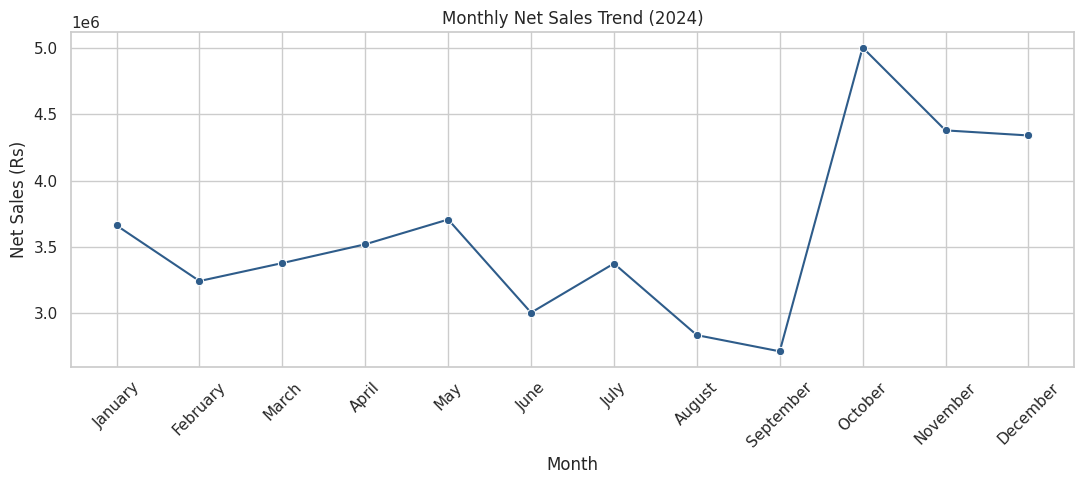

In [6]:
monthly_sales = df.groupby(['month_num','month'])['net_sales'].sum().reset_index().sort_values('month_num')

plt.figure(figsize=(11,5))
sns.lineplot(data=monthly_sales, x='month', y='net_sales', marker='o', sort=False, color='#2E5C8A')
plt.title("Monthly Net Sales Trend (2024)")
plt.xlabel("Month")
plt.ylabel("Net Sales (Rs)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/monthly_trend.png", dpi=150)
plt.show()

**Insight:** Sales rise sharply in October–December, reflecting the festive/holiday shopping season — a pattern that should inform inventory build-up ahead of Q4.

## 5. Regional Performance

/tmp/ipykernel_564/759662961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_revenue.index, y=region_revenue.values, palette="mako")


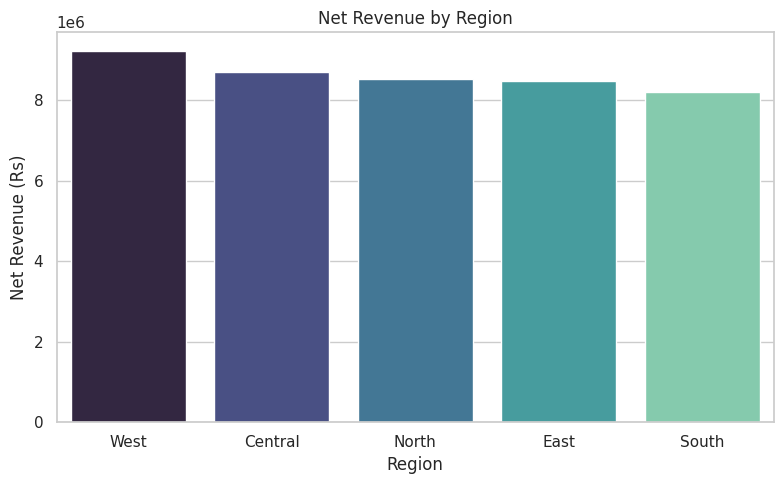

In [7]:
region_revenue = df.groupby('region')['net_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_revenue.index, y=region_revenue.values, palette="mako")
plt.title("Net Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Net Revenue (Rs)")
plt.tight_layout()
plt.savefig("images/revenue_by_region.png", dpi=150)
plt.show()

## 6. Discount Impact on Sales Volume

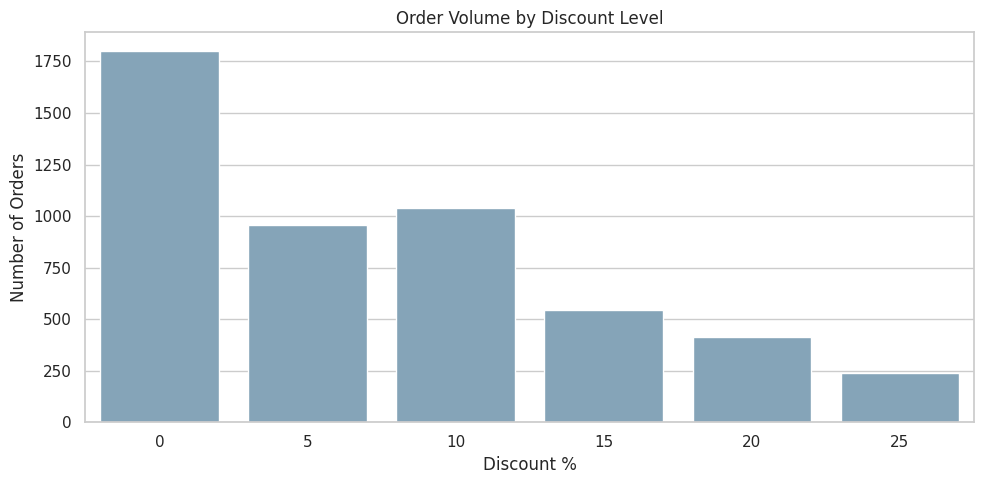

,discount_pct,orders,avg_net_sales
0,0,1801,9256.433032
1,5,958,9203.374969
2,10,1040,8026.646183
3,15,546,7059.828223
4,20,414,8518.303623
5,25,241,8073.573817


In [8]:
discount_analysis = df.groupby('discount_pct').agg(
    orders=('order_id','count'),
    avg_net_sales=('net_sales','mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10,5))
sns.barplot(data=discount_analysis, x='discount_pct', y='orders', ax=ax1, color='#7CA6C0')
ax1.set_ylabel("Number of Orders")
ax1.set_xlabel("Discount %")
ax1.set_title("Order Volume by Discount Level")
plt.tight_layout()
plt.savefig("images/discount_vs_orders.png", dpi=150)
plt.show()

discount_analysis

**Insight:** Moderate discounts (5–10%) drive the highest order volumes without eroding margin as much as steeper discounts (20–25%), which see diminishing returns in order count.

## 7. Payment Mode Preferences

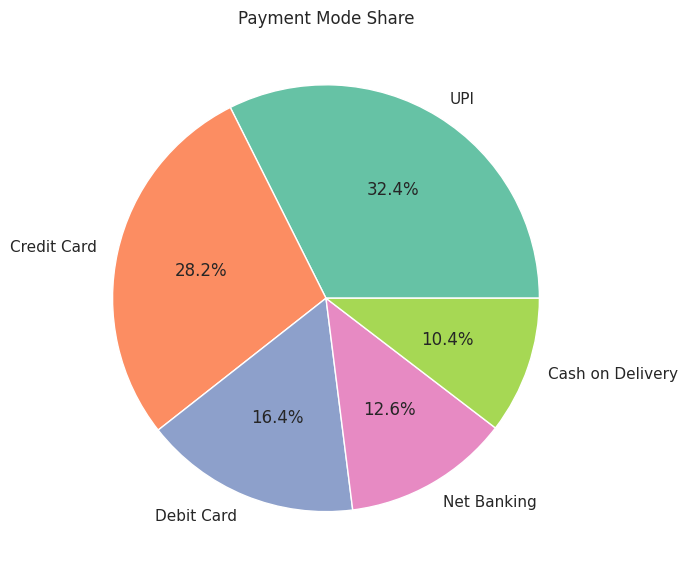

In [9]:
payment_share = df['payment_mode'].value_counts(normalize=True).mul(100).round(1)

plt.figure(figsize=(7,7))
plt.pie(payment_share.values, labels=payment_share.index, autopct='%1.1f%%',
        colors=sns.color_palette("Set2"))
plt.title("Payment Mode Share")
plt.tight_layout()
plt.savefig("images/payment_mode_share.png", dpi=150)
plt.show()

## 8. Correlation Between Numeric Features

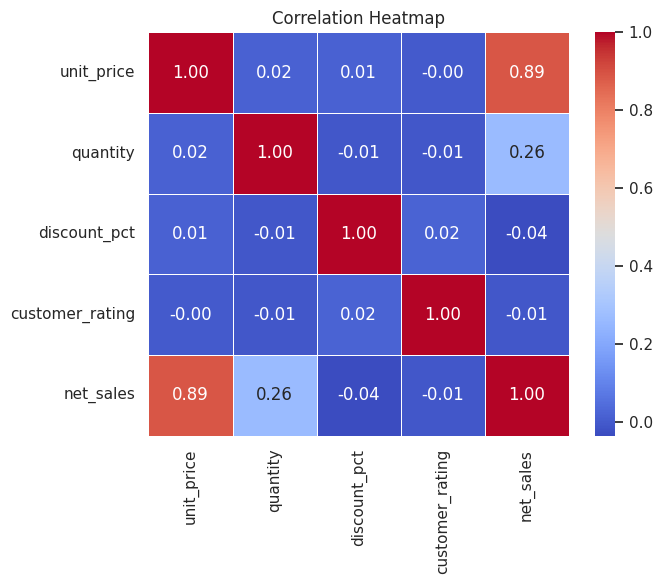

In [10]:
numeric_cols = ['unit_price','quantity','discount_pct','customer_rating','net_sales']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=150)
plt.show()

## 9. Top and Bottom Performing Categories by Average Rating

/tmp/ipykernel_564/1359338543.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_by_category.values, y=rating_by_category.index, palette="crest")


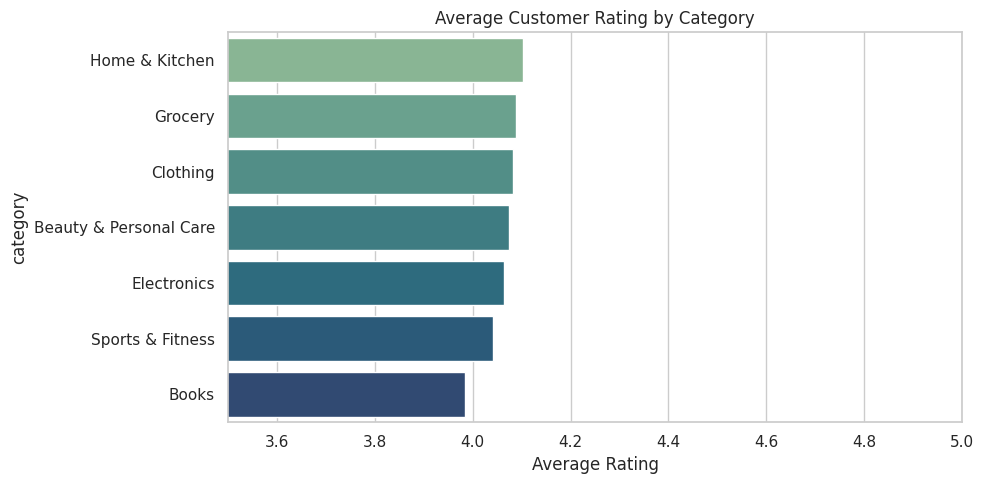

category
Home & Kitchen            4.101786
Grocery                   4.088517
Clothing                  4.082679
Beauty & Personal Care    4.074446
Electronics               4.063662
Sports & Fitness          4.041541
Books                     3.983208
Name: customer_rating, dtype: float64

In [11]:
rating_by_category = df.groupby('category')['customer_rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=rating_by_category.values, y=rating_by_category.index, palette="crest")
plt.title("Average Customer Rating by Category")
plt.xlabel("Average Rating")
plt.xlim(3.5, 5)
plt.tight_layout()
plt.savefig("images/rating_by_category.png", dpi=150)
plt.show()

rating_by_category

## Key Findings & Recommendations

1. **Electronics drives the largest share of revenue** despite a lower order count than Clothing — prioritize inventory and marketing spend here, especially ahead of Q4.
2. **Festive season (Oct–Dec) shows a clear demand spike** — plan stock levels and staffing 6–8 weeks in advance of this window.
3. **UPI and Credit Card are the dominant payment modes**, together covering the majority of transactions — ensure these payment rails have zero downtime during peak sales periods.
4. **Discounts beyond 15% show diminishing returns in order volume**, suggesting the 5–10% range is the more efficient promotional band.
5. **Customer ratings are broadly stable (4.0–4.3) across categories**, with Grocery and Books rated slightly higher, indicating no major quality/satisfaction issue in the current catalog.

---
*This project is part of my Data Analyst portfolio. Dataset is synthetically generated for demonstration purposes, modeled on realistic Indian e-commerce sales patterns.*
